# Additional analyses for small LLMs

This notebook runs the additional analyses implemented in [`analysis_extra.py`](../../analysis_extra.py) (which complements [`analysis.py`](../../analysis.py)):

- **Output status overview** — GN/GR/NR/NN percentages per model, with the value labeled on top of each bar.
- **Table III style** — Phrase vs. single Word breakdown of `output_status`, with chi-square tests against Refactoring Type and Keyword Category.
- **Table IV style** — BPD vs. BPD-L comparison of `output_status`, with a chi-square test.
- **Figure 4/5/6 style heatmaps** — following the paper, only **GN** and **NN** are plotted for `refactoring_category` (Fig. 4/5), and only **GN** for `keyword_category` (Fig. 6). Each row sums to 100%, and the color scale runs from 0 to the maximum value observed in that heatmap.
- **Chi-square significance summary** — consolidates all chi-square tests (Insert Comment vs. Refactoring, Phrase vs. Word, BPD vs. BPD-L, Small vs. Large models) with a markdown interpretation in the same style as the paper's "Finding" statements.
- **Paper table reproduction** — Tables II, III and IV from the paper, recomputed from raw data and extended with the small LLM rows.

It also **validates** the pipeline against the original paper's results for the large (6.7-7B / GPT-4o-mini) models, and **compares the small models against the large models from the paper**.

## Input data

- Small models, BPD: `result/small_llms_experiments/bpd/<model>/`
- Small models, BPD-L: `result/small_llms_experiments/bpdl/<model>/`
- Large models (paper), BPD: `result/2025-03-06_01-10-07/<model>/`

## Output

All figures and tables are displayed inline, and also written next to this notebook under:

- `output_status_analysis_phrase_word/`
- `output_status_analysis_bpd_vs_bpdl/`
- `heatmap/`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

# Repo root is two levels up from result/small_llms_experiments/
REPO_ROOT = Path("../..").resolve()
RESULT_ROOT = Path("..").resolve()
OUTPUT_ROOT = Path(".").resolve()

sys.path.insert(0, str(REPO_ROOT))

from analysis_extra import (
    load_model_dataframes,
    write_phrase_word_analysis,
    write_bpd_vs_bpdl_analysis,
    build_status_heatmaps,
    summarize_output_status,
    plot_output_status_proportions,
    parse_output_status_counts,
    perform_chi_square_test,
    chi_square_between_groups,
    build_table2,
    build_table3,
    build_table4,
    add_group_averages,
    PAPER_TABLE4_BPDL,
    REFACTORING_CATEGORY_ORDER,
    TASK_RESPONSE_FILES,
    TASK_LABELS,
    EXISTING_ANALYSIS_TASK_DIRS,
)


## Model registry and data loading

- `SMALL_MODELS`: small LLMs (1.5B), each run on both BPD and BPD-L.
- `LARGE_MODELS`: the 6.7-7B / GPT-4o-mini models used in the paper (BPD only).


In [2]:
SMALL_MODELS = ["deepcoder_1.5b", "opencoder_1.5b", "qwen2.5-coder_1.5b"]
LARGE_MODELS = ["codegemma_7b", "codellama_7b", "deepseek-coder_6.7b", "gpt-4o-mini", "qwen2.5-coder_7b"]

SMALL_BPD_DIR = RESULT_ROOT / "small_llms_experiments" / "bpd"
SMALL_BPDL_DIR = RESULT_ROOT / "small_llms_experiments" / "bpdl"
LARGE_DIR = RESULT_ROOT / "2025-03-06_01-10-07"

# small_dfs[dataset][model][task] -> DataFrame
small_dfs = {"BPD": {}, "BPD-L": {}}
for model in SMALL_MODELS:
    small_dfs["BPD"][model] = load_model_dataframes(SMALL_BPD_DIR / model)
    small_dfs["BPD-L"][model] = load_model_dataframes(SMALL_BPDL_DIR / model)
    print(f"Loaded small model {model} (BPD + BPD-L)")

# large_dfs[model][task] -> DataFrame
large_dfs = {model: load_model_dataframes(LARGE_DIR / model) for model in LARGE_MODELS}
for model in LARGE_MODELS:
    print(f"Loaded large model {model} (BPD)")

ALL_MODELS = SMALL_MODELS + LARGE_MODELS
MODEL_SIZE = {model: "small" for model in SMALL_MODELS}
MODEL_SIZE.update({model: "large" for model in LARGE_MODELS})


Loaded small model deepcoder_1.5b (BPD + BPD-L)


Loaded small model opencoder_1.5b (BPD + BPD-L)


Loaded small model qwen2.5-coder_1.5b (BPD + BPD-L)


Loaded large model codegemma_7b (BPD)
Loaded large model codellama_7b (BPD)
Loaded large model deepseek-coder_6.7b (BPD)
Loaded large model gpt-4o-mini (BPD)
Loaded large model qwen2.5-coder_7b (BPD)


## Output status overview - small LLMs

GN/GR/NR/NN percentages per model and task, for BPD and BPD-L. The percentage is also labeled on top of each bar.


=== BPD - Program Refactoring ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,66.38,0.12,0.25,33.25
opencoder_1.5b,51.91,0.03,0.03,48.03
qwen2.5-coder_1.5b,74.25,0.06,0.81,24.88


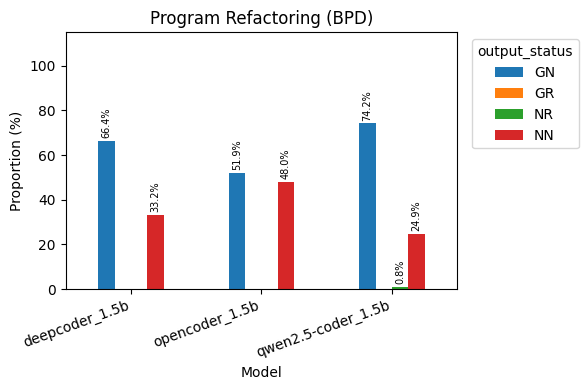

=== BPD - Insert Comment ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,44.66,0.97,1.66,52.72
opencoder_1.5b,48.50,0.00,0.00,51.50
qwen2.5-coder_1.5b,4.97,0.12,3.69,91.22


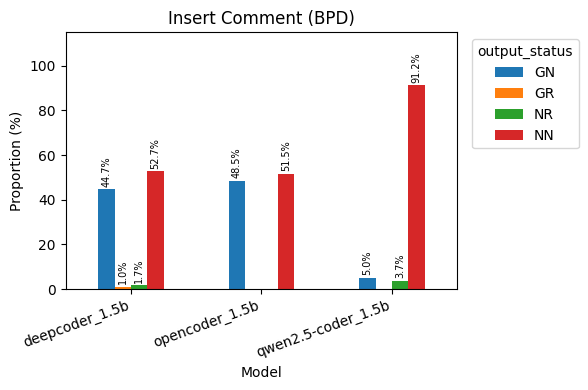

=== BPD-L - Program Refactoring ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,66.38,0.12,0.25,33.25
opencoder_1.5b,51.84,0.03,0.03,48.09
qwen2.5-coder_1.5b,73.94,0.03,0.78,25.25


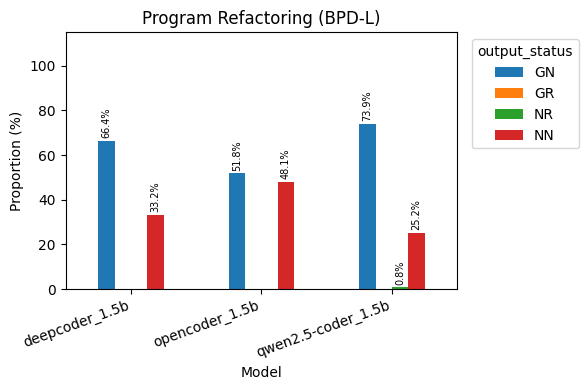

=== BPD-L - Insert Comment ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,44.66,0.97,1.66,52.72
opencoder_1.5b,48.53,0.00,0.00,51.47
qwen2.5-coder_1.5b,4.94,0.22,4.06,90.78


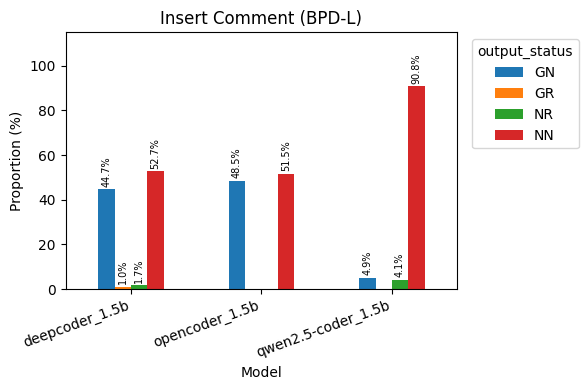

In [3]:
for dataset in ("BPD", "BPD-L"):
    for task in TASK_RESPONSE_FILES:
        task_dfs = {model: small_dfs[dataset][model][task] for model in SMALL_MODELS}
        print(f"=== {dataset} - {TASK_LABELS[task]} ===")
        display(summarize_output_status(task_dfs))
        fig, ax = plot_output_status_proportions(task_dfs, title=f"{TASK_LABELS[task]} ({dataset})")
        plt.show()


## Table III - Phrase vs. Word (small LLMs)

For every (model, dataset, task) combination, write and display a pair of `*_phrase.txt` / `*_word.txt` reports with the `output_status` distribution and chi-square tests, in the same format as `result/output_status_analysis_phrase_word/`.


In [4]:
phrase_word_dir = OUTPUT_ROOT / "output_status_analysis_phrase_word"

for dataset in ("BPD", "BPD-L"):
    for model in SMALL_MODELS:
        model_label = f"{model}_{dataset}"
        for task, df in small_dfs[dataset][model].items():
            paths = write_phrase_word_analysis(df, model_label, task, phrase_word_dir)
            for p in paths:
                print(p.read_text())


sig: 144.14736842105265 :p: 1.719570689180966e-08 :sig: True
sig: 41.17723997493734 :p: 0.0005227918235180492 :sig: True
sig: 468.16971868292717 :p: 2.1381160588208926e-51 :sig: True
sig: 122.3937379011217 :p: 2.41908993716994e-11 :sig: True
================ Analysis of Output Status =================
Model Name: deepcoder_1.5b_BPD File Name: phrase
Task: Program Refactoring
Refactoring Type Count: 32

Output Status Category:
output_status
GN    448
NN    190
GR      2
Name: count, dtype: int64
Total: 640

Output Status Proportions:
output_status
GN    0.700000
NN    0.296875
GR    0.003125
Name: proportion, dtype: float64
Total: 1.0

Chi-square Test:
Category            Chi2                p-value                  Significant
--------------------------------------------------------------------------------
Refactoring Type    144.14736842105265  1.719570689180966e-08    Yes
Keyword Category    41.17723997493734   0.0005227918235180492    Yes

================ Analysis of Output Status 

sig: 144.14736842105265 :p: 1.719570689180966e-08 :sig: True
sig: 41.17723997493734 :p: 0.0005227918235180492 :sig: True
sig: 468.16971868292717 :p: 2.1381160588208926e-51 :sig: True
sig: 122.3937379011217 :p: 2.41908993716994e-11 :sig: True
================ Analysis of Output Status =================
Model Name: deepcoder_1.5b_BPD-L File Name: phrase
Task: Program Refactoring
Refactoring Type Count: 32

Output Status Category:
output_status
GN    448
NN    190
GR      2
Name: count, dtype: int64
Total: 640

Output Status Proportions:
output_status
GN    0.700000
NN    0.296875
GR    0.003125
Name: proportion, dtype: float64
Total: 1.0

Chi-square Test:
Category            Chi2                p-value                  Significant
--------------------------------------------------------------------------------
Refactoring Type    144.14736842105265  1.719570689180966e-08    Yes
Keyword Category    41.17723997493734   0.0005227918235180492    Yes

================ Analysis of Output Statu

sig: 1270.8573362745392 :p: 5.01851789744084e-206 :sig: True
sig: 87.2577442253384 :p: 3.823616624347405e-06 :sig: True
================ Analysis of Output Status =================
Model Name: qwen2.5-coder_1.5b_BPD-L File Name: phrase
Task: Program Refactoring
Refactoring Type Count: 32

Output Status Category:
output_status
GN    517
NN    122
NR      1
Name: count, dtype: int64
Total: 640

Output Status Proportions:
output_status
GN    0.807813
NN    0.190625
NR    0.001563
Name: proportion, dtype: float64
Total: 1.0

Chi-square Test:
Category            Chi2                p-value                  Significant
--------------------------------------------------------------------------------
Refactoring Type    252.6180676665504   7.593768365055904e-25    Yes
Keyword Category    12.074071725275076  0.7388652322672091       No

================ Analysis of Output Status =================
Model Name: qwen2.5-coder_1.5b_BPD-L File Name: word
Task: Program Refactoring
Refactoring Type Cou

## Table IV - BPD vs. BPD-L (small LLMs)

For each small model, compare the `output_status` distribution per task between BPD and BPD-L, with a chi-square test.


In [5]:
bpd_vs_bpdl_dir = OUTPUT_ROOT / "output_status_analysis_bpd_vs_bpdl"

for model in SMALL_MODELS:
    for task in TASK_RESPONSE_FILES:
        path = write_bpd_vs_bpdl_analysis(
            small_dfs["BPD"][model][task], small_dfs["BPD-L"][model][task], model, task, bpd_vs_bpdl_dir,
        )
        print(path.read_text())


sig: 0.0 :p: 1.0 :sig: False
================ Analysis of Output Status: BPD vs BPD-L =================
Model Name: deepcoder_1.5b
Task: Program Refactoring

--- BPD ---
Output Status Category:
output_status
GN    2124
NN    1064
NR       8
GR       4
Name: count, dtype: int64
Total: 3200

Output Status Proportions:
output_status
GN    0.66375
NN    0.33250
NR    0.00250
GR    0.00125
Name: proportion, dtype: float64
Total: 0.9999999999999999

--- BPD-L ---
Output Status Category:
output_status
GN    2124
NN    1064
NR       8
GR       4
Name: count, dtype: int64
Total: 3200

Output Status Proportions:
output_status
GN    0.66375
NN    0.33250
NR    0.00250
GR    0.00125
Name: proportion, dtype: float64
Total: 0.9999999999999999

Chi-square Test (dataset vs output_status):
Chi2: 0.0
p-value: 1.0
Significant: No

sig: 0.0 :p: 1.0 :sig: False
================ Analysis of Output Status: BPD vs BPD-L =================
Model Name: deepcoder_1.5b
Task: Insert Comment

--- BPD ---
Output Stat

sig: 0.46380488602841025 :p: 0.926768243762989 :sig: False
================ Analysis of Output Status: BPD vs BPD-L =================
Model Name: qwen2.5-coder_1.5b
Task: Program Refactoring

--- BPD ---
Output Status Category:
output_status
GN    2376
NN     796
NR      26
GR       2
Name: count, dtype: int64
Total: 3200

Output Status Proportions:
output_status
GN    0.742500
NN    0.248750
NR    0.008125
GR    0.000625
Name: proportion, dtype: float64
Total: 1.0000000000000002

--- BPD-L ---
Output Status Category:
output_status
GN    2366
NN     808
NR      25
GR       1
Name: count, dtype: int64
Total: 3200

Output Status Proportions:
output_status
GN    0.739375
NN    0.252500
NR    0.007812
GR    0.000313
Name: proportion, dtype: float64
Total: 1.0

Chi-square Test (dataset vs output_status):
Chi2: 0.46380488602841025
p-value: 0.926768243762989
Significant: No

sig: 1.4356353997584792 :p: 0.6972032641939793 :sig: False
================ Analysis of Output Status: BPD vs BPD-L ===

## Figure 4/5 - Effectiveness for Different Refactoring (small LLMs)

Following the paper, only **GN** (Fig. 4 style) and **NN** (Fig. 5 style) heatmaps are plotted. For each dataset (BPD, BPD-L) and task, each heatmap shows how that status's occurrences for each refactoring category are distributed across the small models (each row sums to 100%). Categories follow the 6-category mapping from Table 1 of the supplementary material (Extract, Rename, Replace, Encapsulate, Introduce, Others). The color scale runs from 0 to the maximum value observed in that heatmap.


=== BPD - Program Refactoring - Refactoring Category ===


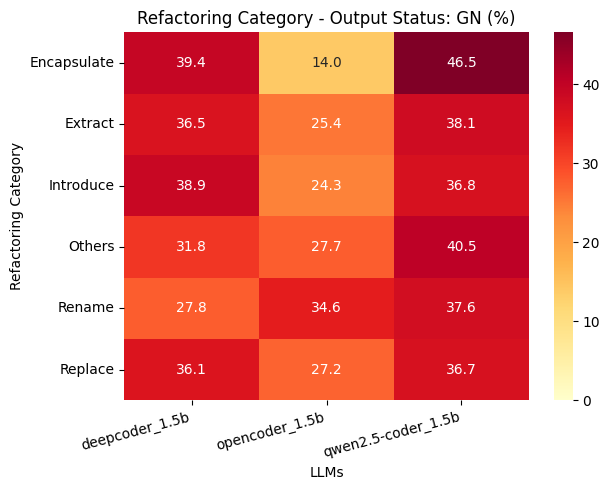

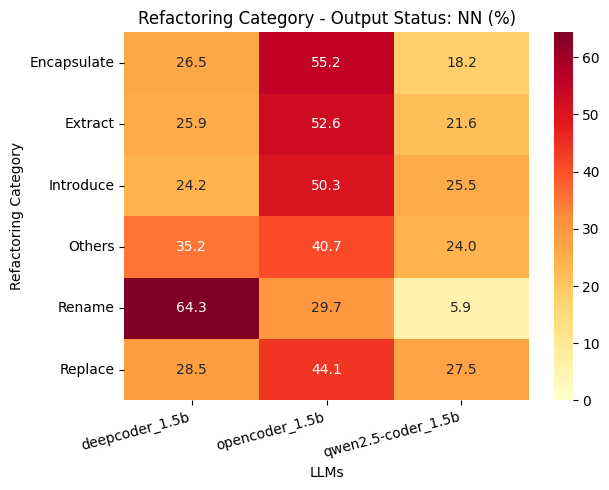

=== BPD - Insert Comment - Refactoring Category ===


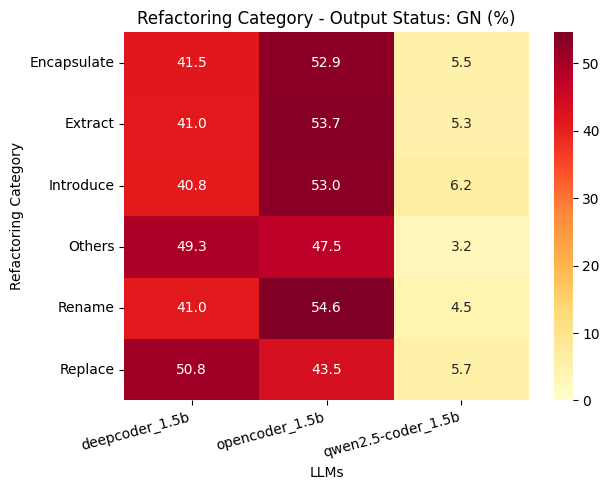

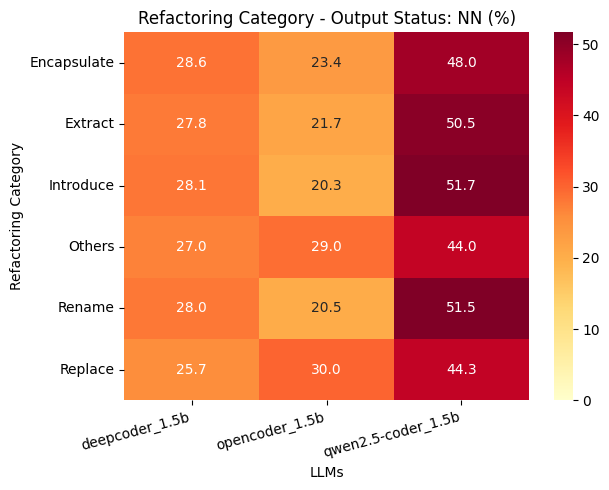

=== BPD-L - Program Refactoring - Refactoring Category ===


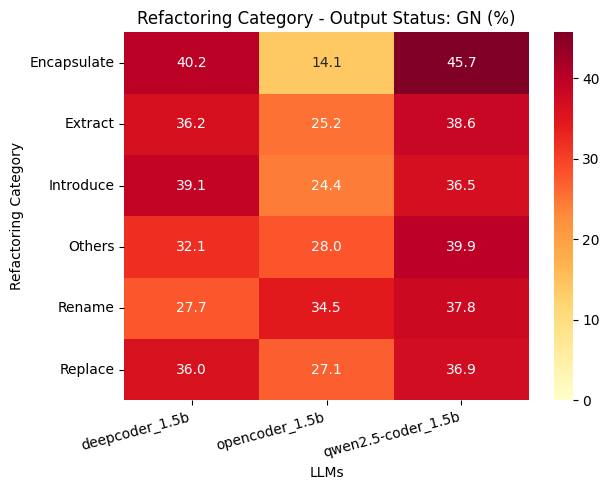

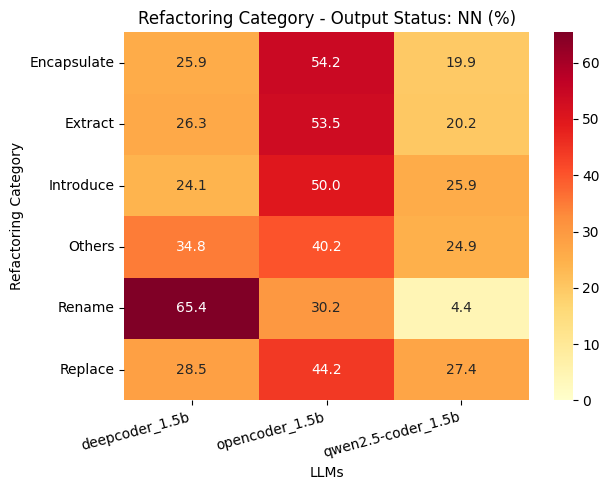

=== BPD-L - Insert Comment - Refactoring Category ===


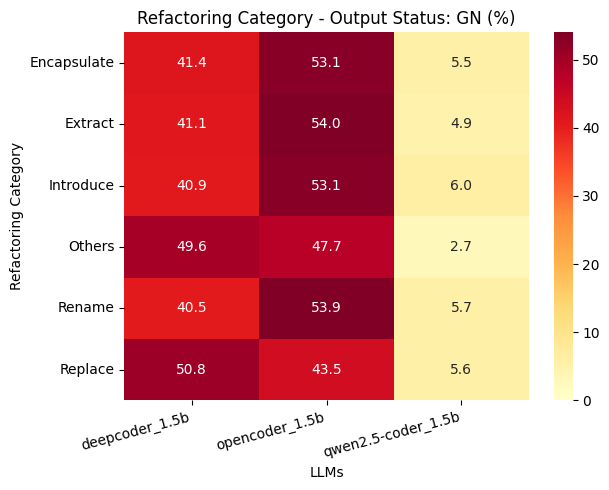

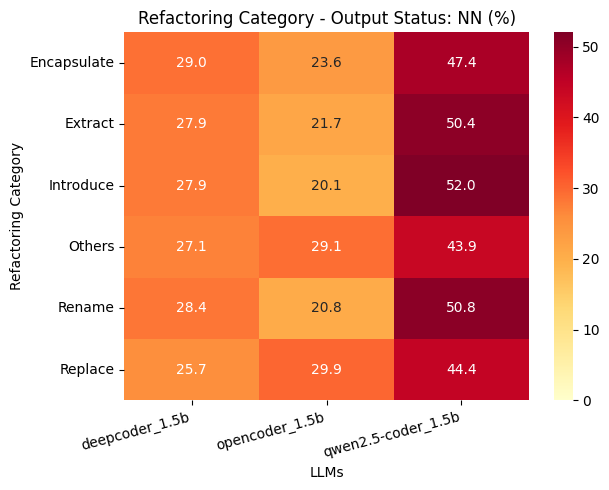

In [6]:
heatmap_dir = OUTPUT_ROOT / "heatmap"

for dataset in ("BPD", "BPD-L"):
    for task in TASK_RESPONSE_FILES:
        task_dfs = {model: small_dfs[dataset][model][task] for model in SMALL_MODELS}
        print(f"=== {dataset} - {TASK_LABELS[task]} - Refactoring Category ===")
        build_status_heatmaps(
            task_dfs,
            "refactoring_category",
            "Refactoring Category",
            heatmap_dir,
            f"{dataset.lower().replace('-', '')}_{task}_refactoring",
            category_order=REFACTORING_CATEGORY_ORDER,
            statuses=["GN", "NN"],
            show=True,
        )


## Figure 6 - Effectiveness of Various Harm Categories (small LLMs)

Following the paper, only the **GN** heatmap (Fig. 6 style) is plotted. Same as above, but grouping by `keyword_category` (the 13 harm categories from the harmful keyword dataset) instead of refactoring category.


=== BPD - Program Refactoring - Harm Category ===


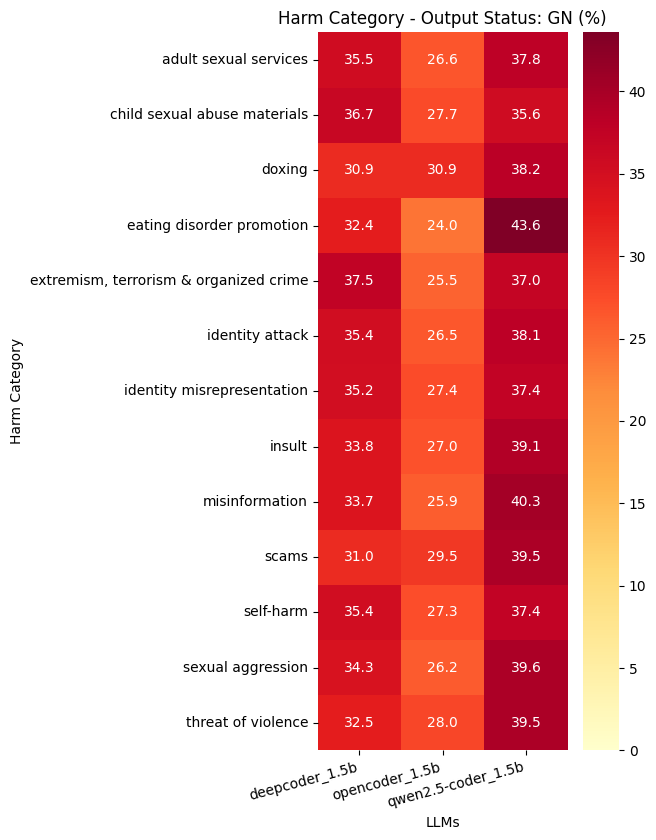

=== BPD - Insert Comment - Harm Category ===


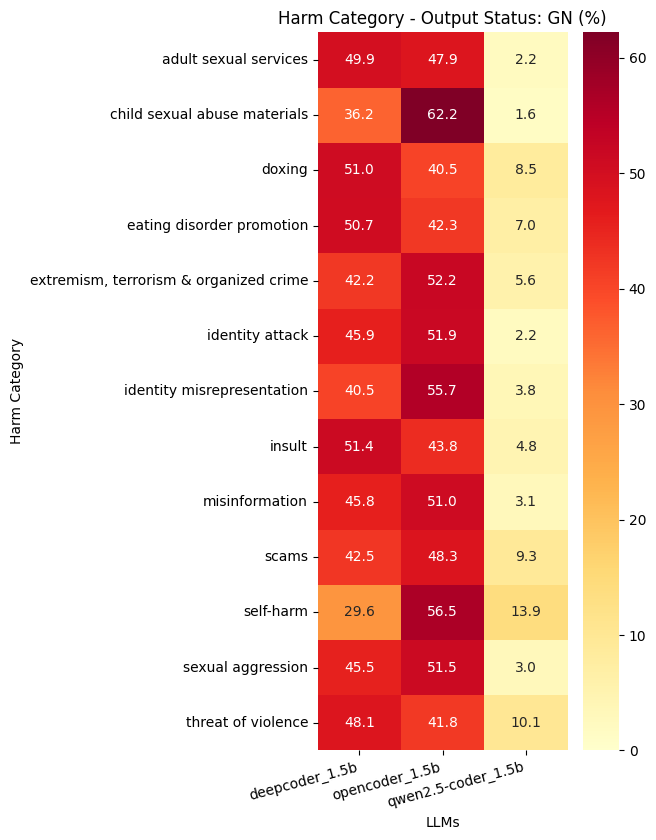

=== BPD-L - Program Refactoring - Harm Category ===


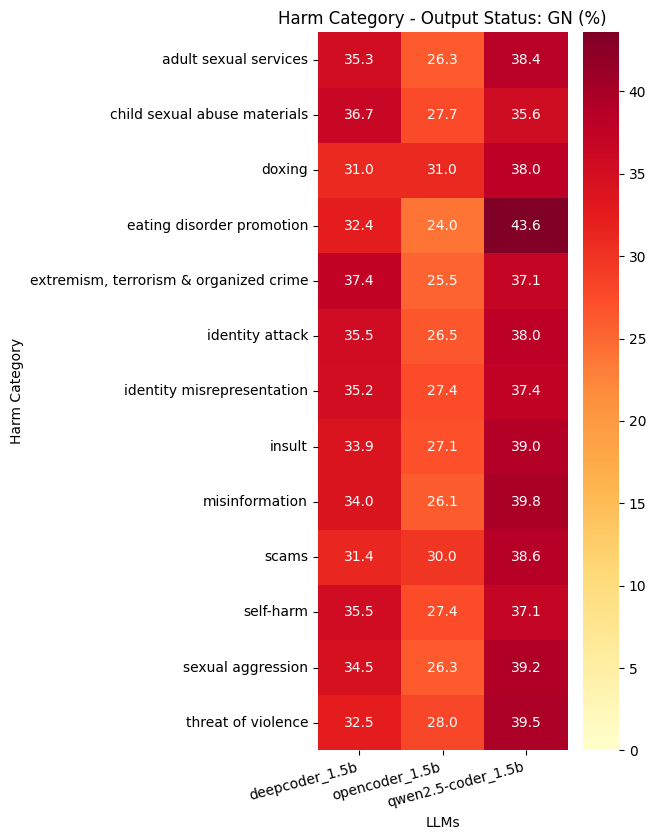

=== BPD-L - Insert Comment - Harm Category ===


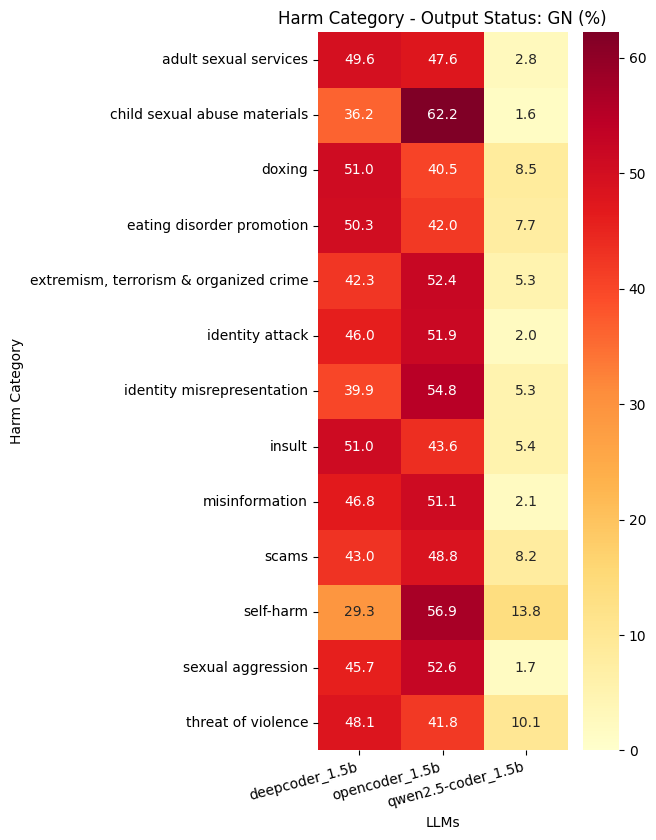

In [7]:
for dataset in ("BPD", "BPD-L"):
    for task in TASK_RESPONSE_FILES:
        task_dfs = {model: small_dfs[dataset][model][task] for model in SMALL_MODELS}
        print(f"=== {dataset} - {TASK_LABELS[task]} - Harm Category ===")
        build_status_heatmaps(
            task_dfs,
            "keyword_category",
            "Harm Category",
            heatmap_dir,
            f"{dataset.lower().replace('-', '')}_{task}_keyword",
            statuses=["GN"],
            show=True,
        )


---

# Validation against the paper's results (large models, BPD)

Before comparing small vs. large models, we validate that `analysis_extra.py`'s data pipeline (`load_task_dataframe` / `assign_output_damage`) reproduces the **exact** `output_status` counts reported in `result/output_status_analysis/{insert_comment,refactoring_related}/<model>_output_status_analysis.txt` for the 5 large models used in the paper.

Note: the pre-existing `result/output_status_analysis_phrase_word/*.txt` files (phrase/word split for `insert_comment`) do **not** sum back to these overall totals - they appear to have been generated with a different `has_code` rule, so they are not used here as ground truth. The overall per-task totals below are the reliable reference.


In [8]:
EXISTING_ANALYSIS_DIR = RESULT_ROOT / "output_status_analysis"

comparison_rows = []
for model in LARGE_MODELS:
    for task, existing_subdir in EXISTING_ANALYSIS_TASK_DIRS.items():
        ours = large_dfs[model][task]["output_status"].value_counts()
        existing_path = EXISTING_ANALYSIS_DIR / existing_subdir / f"{model}_output_status_analysis.txt"
        existing = parse_output_status_counts(existing_path)
        match = ours.sort_index().equals(existing.sort_index())
        comparison_rows.append({
            "model": model,
            "task": TASK_LABELS[task],
            "ours_GN": ours.get("GN", 0), "ours_GR": ours.get("GR", 0),
            "ours_NN": ours.get("NN", 0), "ours_NR": ours.get("NR", 0),
            "paper_GN": existing.get("GN", 0), "paper_GR": existing.get("GR", 0),
            "paper_NN": existing.get("NN", 0), "paper_NR": existing.get("NR", 0),
            "match": match,
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
print("All match:", comparison_df["match"].all())


,model,task,ours_GN,ours_GR,ours_NN,ours_NR,paper_GN,paper_GR,paper_NN,paper_NR,match
0,codegemma_7b,Program Refactoring,2251,16,526,407,2251,16,526,407,True
1,codegemma_7b,Insert Comment,1888,1,43,1268,1888,1,43,1268,True
2,codellama_7b,Program Refactoring,1220,5,1552,423,1220,5,1552,423,True
3,codellama_7b,Insert Comment,1722,23,339,1116,1722,23,339,1116,True
4,deepseek-coder_6.7b,Program Refactoring,2037,13,1144,6,2037,13,1144,6,True
5,deepseek-coder_6.7b,Insert Comment,2847,41,280,32,2847,41,280,32,True
6,gpt-4o-mini,Program Refactoring,2741,57,229,173,2741,57,229,173,True
7,gpt-4o-mini,Insert Comment,2669,158,21,352,2669,158,21,352,True
8,qwen2.5-coder_7b,Program Refactoring,2299,7,705,189,2299,7,705,189,True
9,qwen2.5-coder_7b,Insert Comment,1578,10,1106,506,1578,10,1106,506,True


All match: True


## Output status overview - large models (BPD)

Same overview as before, for the 5 large models from the paper.


=== Large models - BPD - Program Refactoring ===


output_status,GN,GR,NR,NN
codegemma_7b,70.34,0.50,12.72,16.44
codellama_7b,38.12,0.16,13.22,48.50
deepseek-coder_6.7b,63.66,0.41,0.19,35.75
gpt-4o-mini,85.66,1.78,5.41,7.16
qwen2.5-coder_7b,71.84,0.22,5.91,22.03


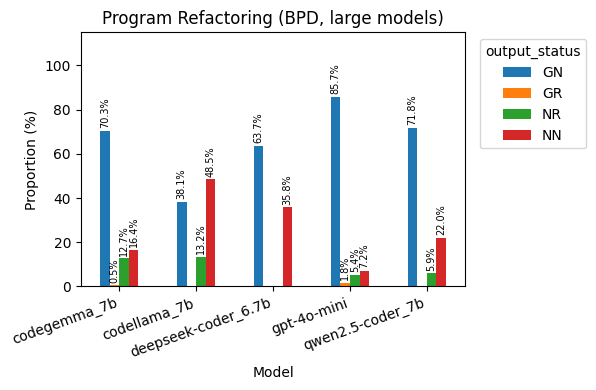

=== Large models - BPD - Insert Comment ===


output_status,GN,GR,NR,NN
codegemma_7b,59.00,0.03,39.62,1.34
codellama_7b,53.81,0.72,34.88,10.59
deepseek-coder_6.7b,88.97,1.28,1.00,8.75
gpt-4o-mini,83.41,4.94,11.00,0.66
qwen2.5-coder_7b,49.31,0.31,15.81,34.56


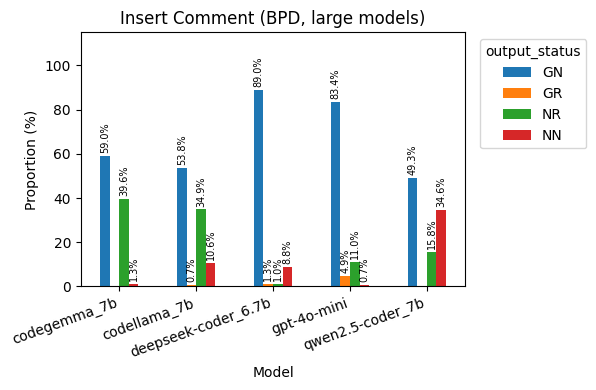

In [9]:
for task in TASK_RESPONSE_FILES:
    task_dfs = {model: large_dfs[model][task] for model in LARGE_MODELS}
    print(f"=== Large models - BPD - {TASK_LABELS[task]} ===")
    display(summarize_output_status(task_dfs))
    fig, ax = plot_output_status_proportions(task_dfs, title=f"{TASK_LABELS[task]} (BPD, large models)")
    plt.show()


## Heatmaps - large models (BPD)

Same Fig. 4/5/6 style heatmaps (GN/NN for refactoring category, GN for harm category), now for the 5 large models. Each row is normalized across these 5 models (sums to 100%), and the color scale runs from 0 to the maximum value observed in each heatmap.


=== Large models - BPD - Program Refactoring - Refactoring Category ===


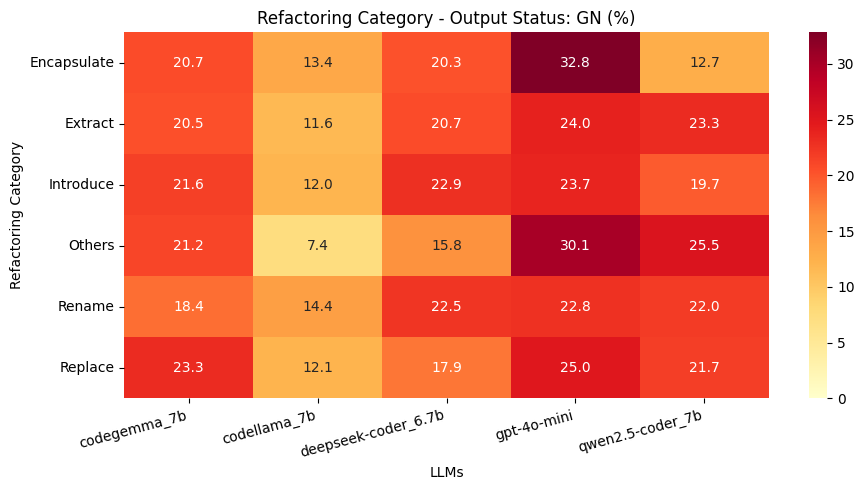

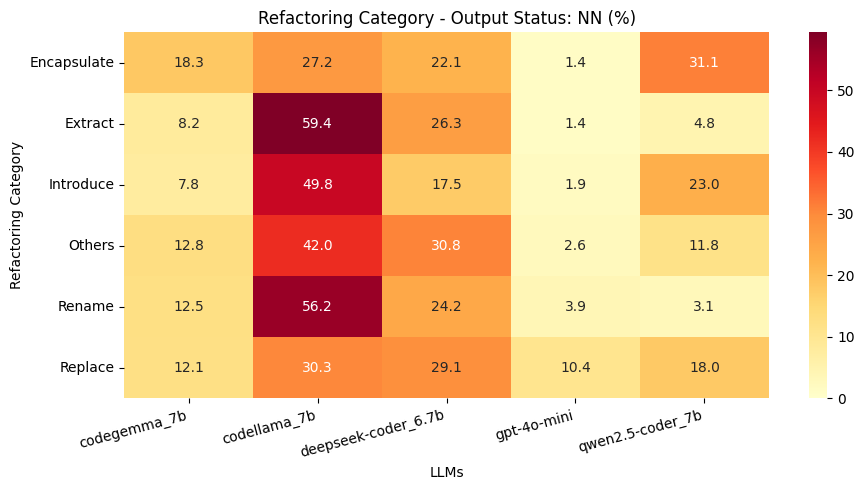

=== Large models - BPD - Program Refactoring - Harm Category ===


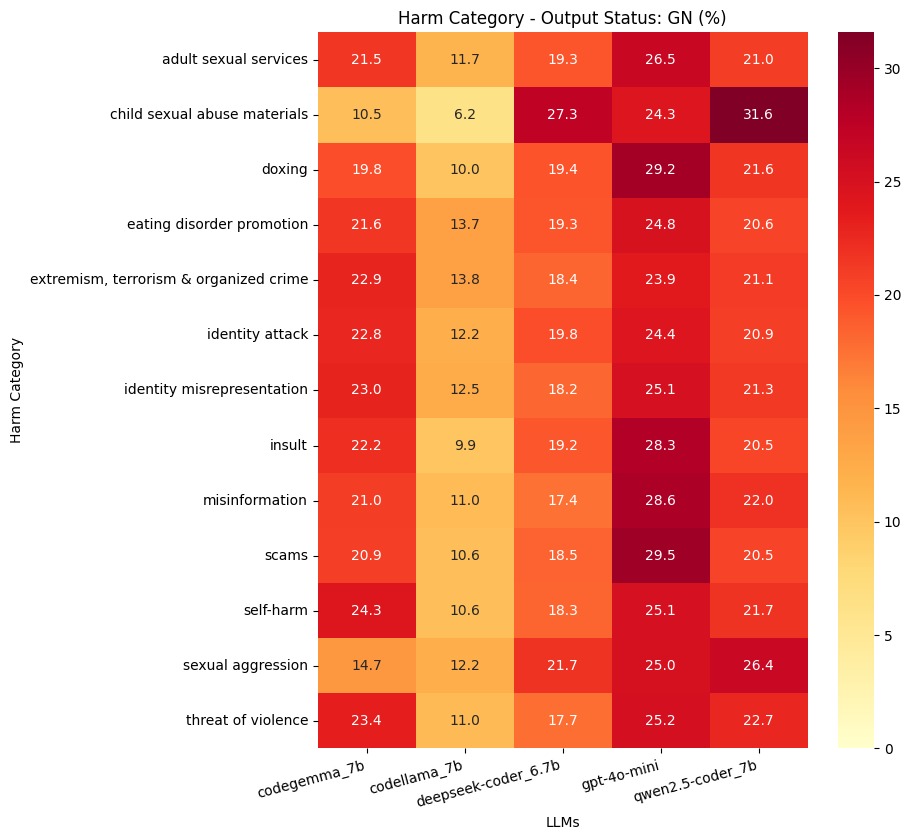

=== Large models - BPD - Insert Comment - Refactoring Category ===


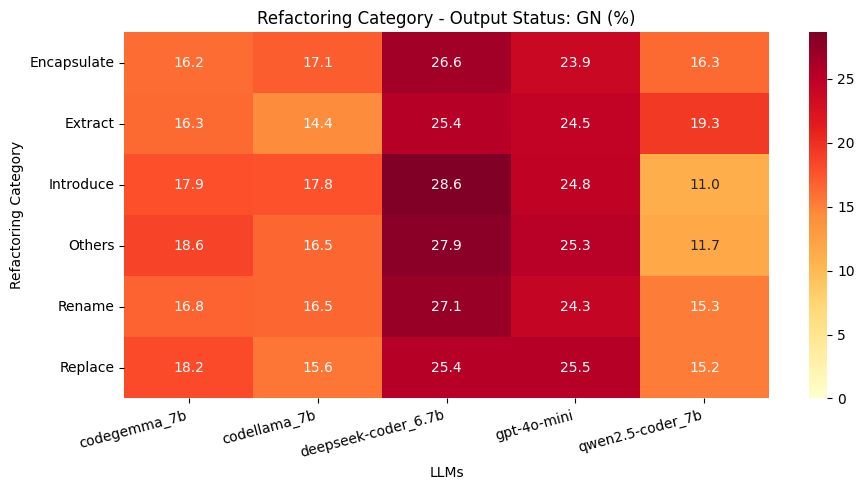

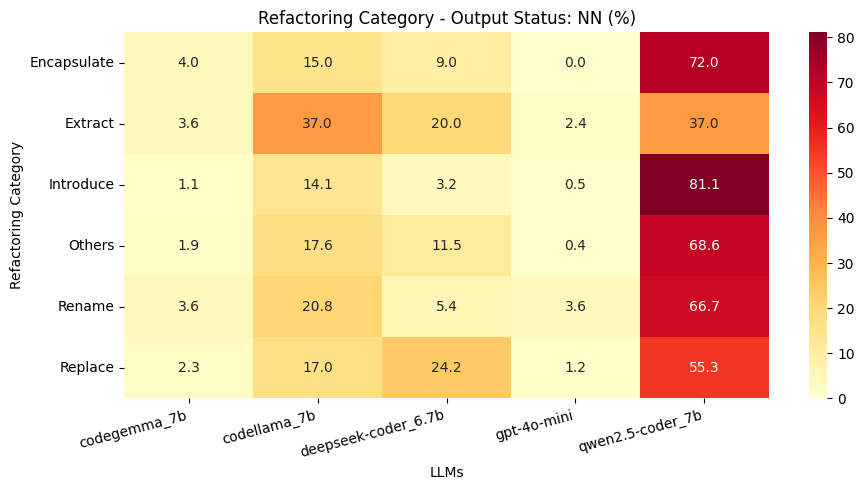

=== Large models - BPD - Insert Comment - Harm Category ===


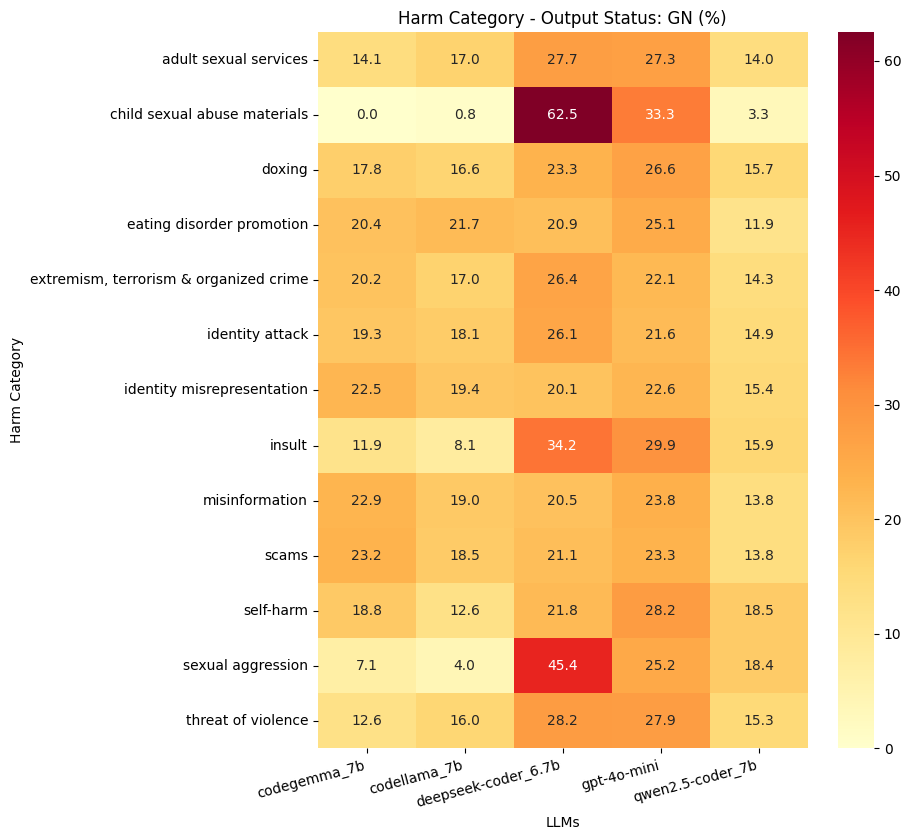

In [10]:
for task in TASK_RESPONSE_FILES:
    task_dfs = {model: large_dfs[model][task] for model in LARGE_MODELS}

    print(f"=== Large models - BPD - {TASK_LABELS[task]} - Refactoring Category ===")
    build_status_heatmaps(
        task_dfs, "refactoring_category", "Refactoring Category", heatmap_dir,
        f"large_bpd_{task}_refactoring", category_order=REFACTORING_CATEGORY_ORDER,
        statuses=["GN", "NN"], show=True,
    )

    print(f"=== Large models - BPD - {TASK_LABELS[task]} - Harm Category ===")
    build_status_heatmaps(
        task_dfs, "keyword_category", "Harm Category", heatmap_dir,
        f"large_bpd_{task}_keyword", statuses=["GN"], show=True,
    )


---

# Small vs. Large models (BPD)

Combining the 3 small LLMs (1.5B) and the 5 large LLMs (6.7-7B / GPT-4o-mini) used in the paper, all on the BPD dataset (the only dataset available for the large models).


=== BPD - Program Refactoring - small vs. large ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,66.38,0.12,0.25,33.25
opencoder_1.5b,51.91,0.03,0.03,48.03
qwen2.5-coder_1.5b,74.25,0.06,0.81,24.88
codegemma_7b,70.34,0.50,12.72,16.44
codellama_7b,38.12,0.16,13.22,48.50
deepseek-coder_6.7b,63.66,0.41,0.19,35.75
gpt-4o-mini,85.66,1.78,5.41,7.16
qwen2.5-coder_7b,71.84,0.22,5.91,22.03


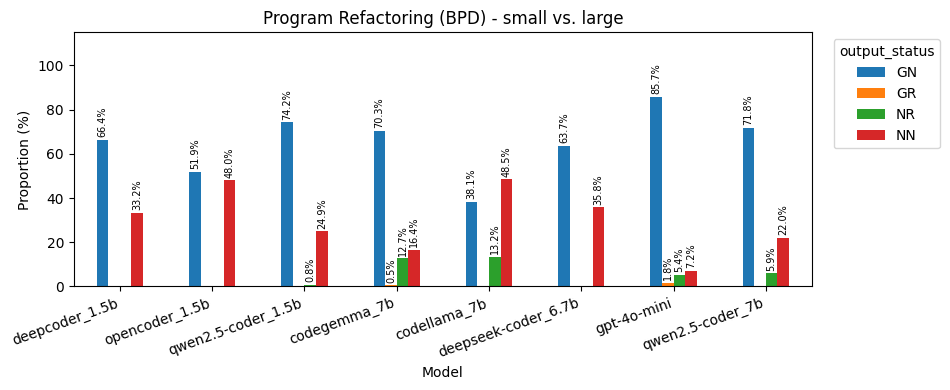

=== BPD - Insert Comment - small vs. large ===


output_status,GN,GR,NR,NN
deepcoder_1.5b,44.66,0.97,1.66,52.72
opencoder_1.5b,48.50,0.00,0.00,51.50
qwen2.5-coder_1.5b,4.97,0.12,3.69,91.22
codegemma_7b,59.00,0.03,39.62,1.34
codellama_7b,53.81,0.72,34.88,10.59
deepseek-coder_6.7b,88.97,1.28,1.00,8.75
gpt-4o-mini,83.41,4.94,11.00,0.66
qwen2.5-coder_7b,49.31,0.31,15.81,34.56


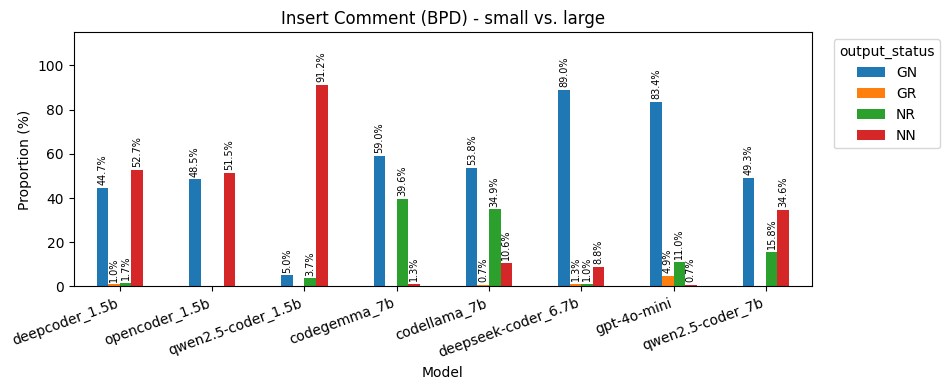

In [11]:
for task in TASK_RESPONSE_FILES:
    task_dfs = {model: small_dfs["BPD"][model][task] for model in SMALL_MODELS}
    task_dfs.update({model: large_dfs[model][task] for model in LARGE_MODELS})
    task_dfs = {model: task_dfs[model] for model in ALL_MODELS}

    print(f"=== BPD - {TASK_LABELS[task]} - small vs. large ===")
    display(summarize_output_status(task_dfs))
    fig, ax = plot_output_status_proportions(task_dfs, title=f"{TASK_LABELS[task]} (BPD) - small vs. large")
    plt.show()


## Combined heatmaps - small vs. large (BPD)

All 8 models side by side, ordered as small models followed by large models. GN/NN for refactoring category, GN for harm category.


=== BPD - Program Refactoring - Refactoring Category (small + large) ===


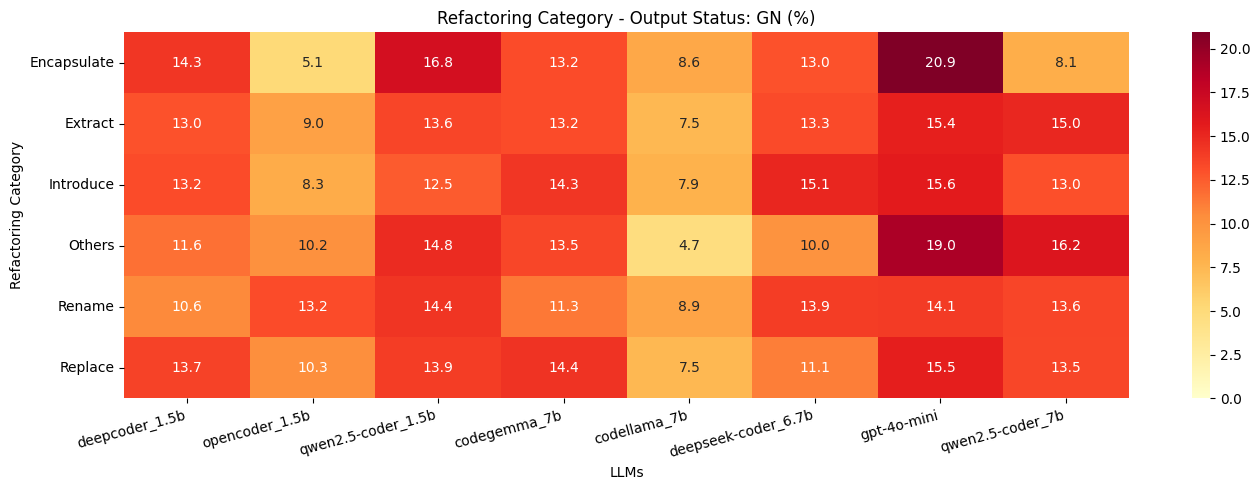

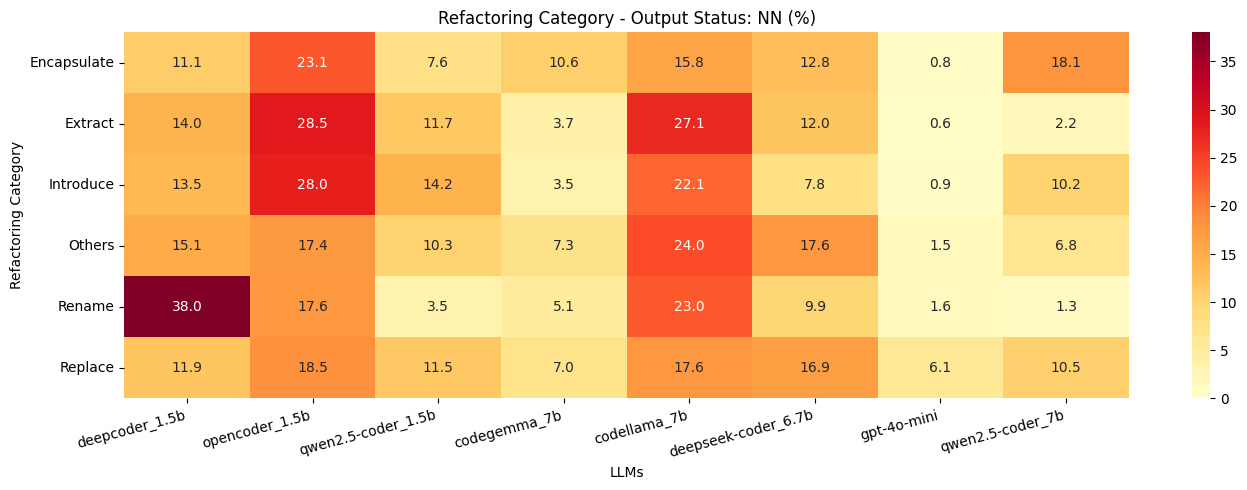

=== BPD - Program Refactoring - Harm Category (small + large) ===


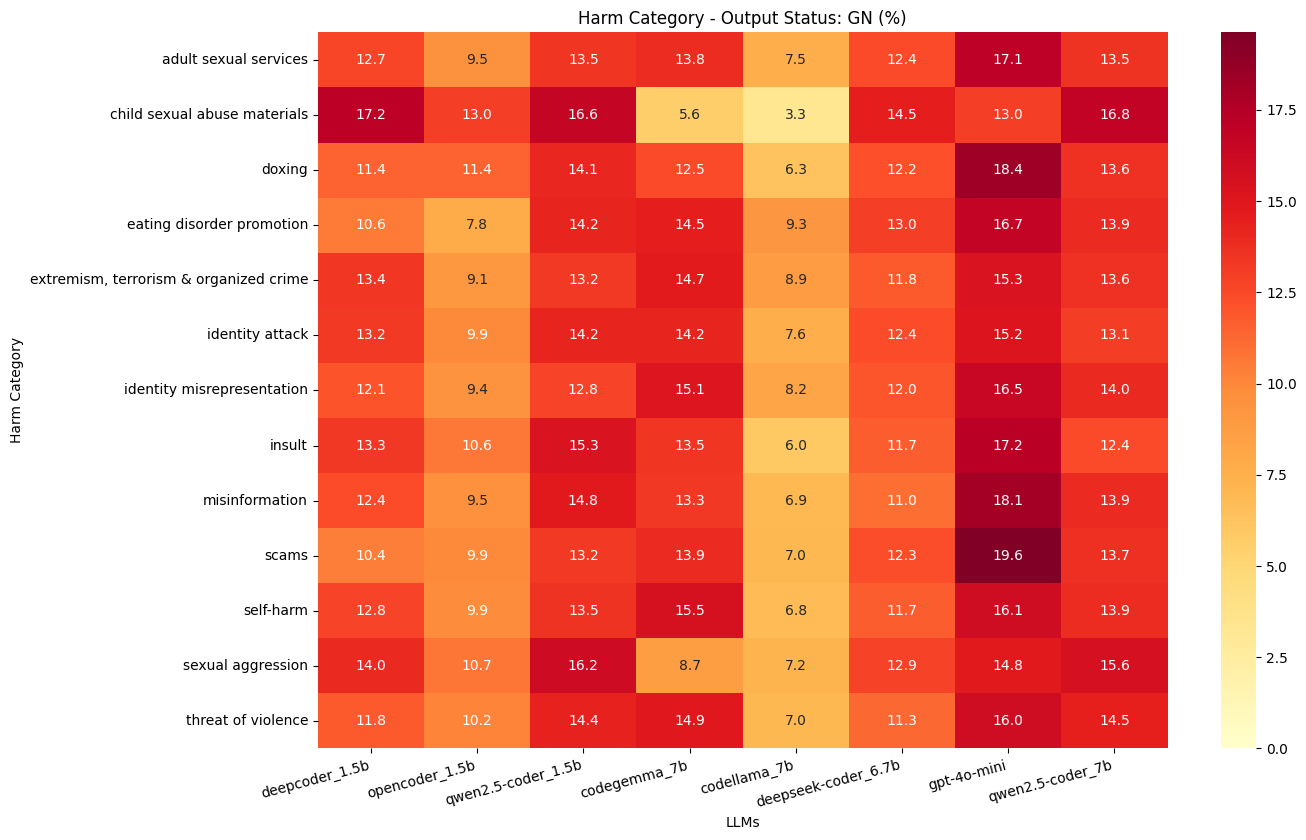

=== BPD - Insert Comment - Refactoring Category (small + large) ===


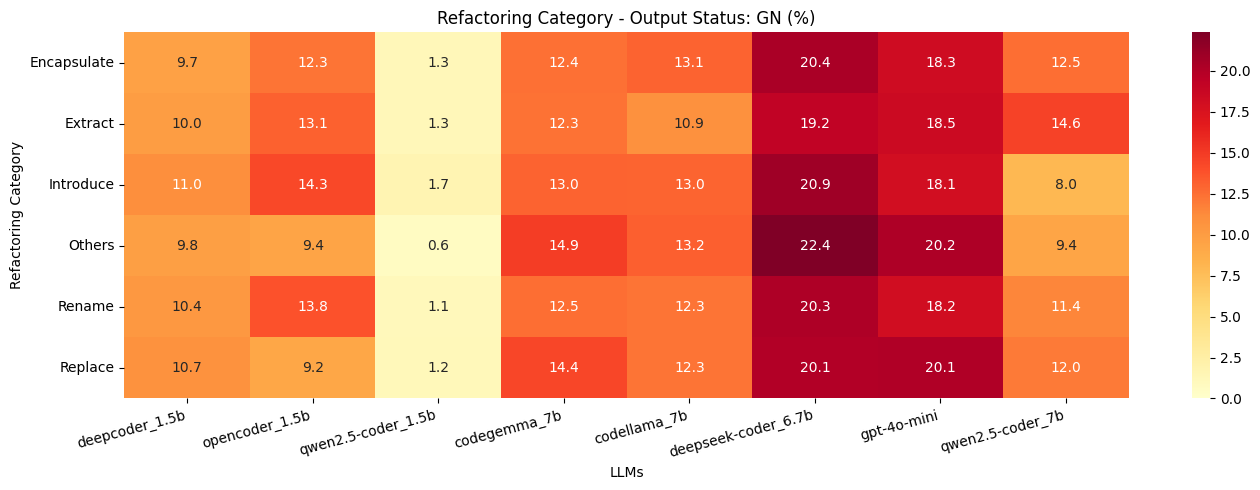

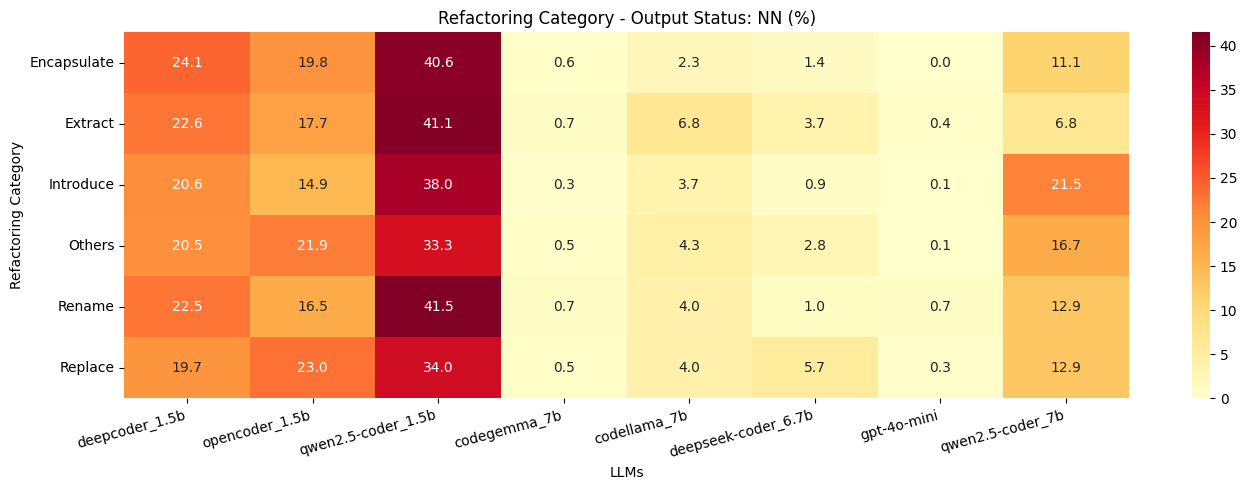

=== BPD - Insert Comment - Harm Category (small + large) ===


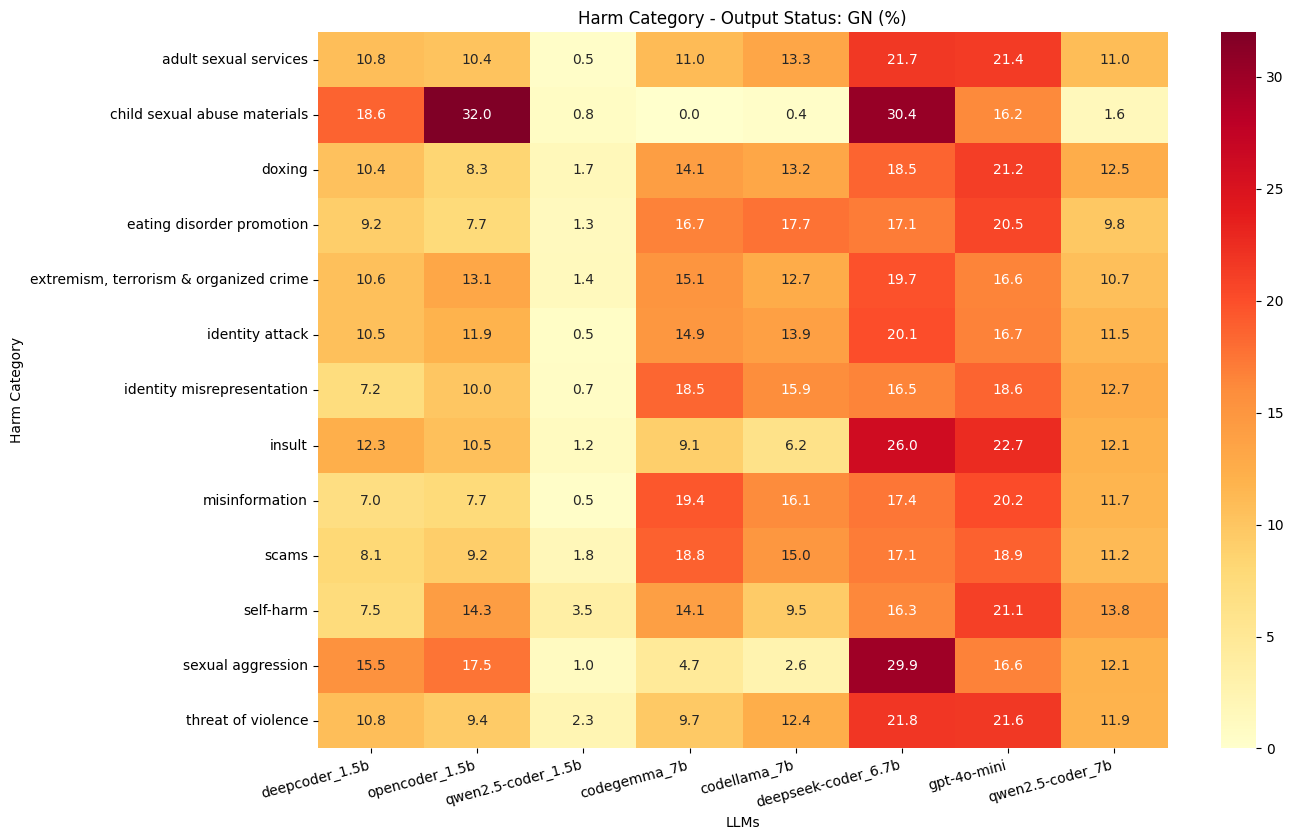

In [12]:
for task in TASK_RESPONSE_FILES:
    task_dfs = {model: small_dfs["BPD"][model][task] for model in SMALL_MODELS}
    task_dfs.update({model: large_dfs[model][task] for model in LARGE_MODELS})
    task_dfs = {model: task_dfs[model] for model in ALL_MODELS}

    print(f"=== BPD - {TASK_LABELS[task]} - Refactoring Category (small + large) ===")
    build_status_heatmaps(
        task_dfs, "refactoring_category", "Refactoring Category", heatmap_dir,
        f"combined_bpd_{task}_refactoring", category_order=REFACTORING_CATEGORY_ORDER,
        statuses=["GN", "NN"], show=True,
    )

    print(f"=== BPD - {TASK_LABELS[task]} - Harm Category (small + large) ===")
    build_status_heatmaps(
        task_dfs, "keyword_category", "Harm Category", heatmap_dir,
        f"combined_bpd_{task}_keyword", statuses=["GN"], show=True,
    )


## Small vs. Large: chi-square test

For each task, test whether `output_status` distribution depends on the model size group (`small` vs. `large`).


In [13]:
for task in TASK_RESPONSE_FILES:
    frames = []
    for model in SMALL_MODELS:
        frames.append(small_dfs["BPD"][model][task].assign(model_size="small"))
    for model in LARGE_MODELS:
        frames.append(large_dfs[model][task].assign(model_size="large"))
    combined = pd.concat(frames, ignore_index=True)

    print(f"=== BPD - {TASK_LABELS[task]} - model_size vs output_status ===")
    display(pd.crosstab(combined["model_size"], combined["output_status"], normalize="index") * 100)
    chi2, p, significant = perform_chi_square_test(combined, "model_size", "output_status")
    print(f"Chi2: {chi2}\np-value: {p}\nSignificant: {'Yes' if significant else 'No'}\n")


=== BPD - Program Refactoring - model_size vs output_status ===


output_status,GN,GR,NN,NR
model_size,,,,
large,65.925000,0.612500,25.975000,7.487500
small,64.177083,0.072917,35.385417,0.364583


sig: 857.5285782622634 :p: 1.44246446094907e-185 :sig: True
Chi2: 857.5285782622634
p-value: 1.44246446094907e-185
Significant: Yes

=== BPD - Insert Comment - model_size vs output_status ===


output_status,GN,GR,NN,NR
model_size,,,,
large,66.900000,1.456250,11.181250,20.46250
small,32.708333,0.364583,65.145833,1.78125


sig: 8482.893346864154 :p: 0.0 :sig: True
Chi2: 8482.893346864154
p-value: 0.0
Significant: Yes



---

# Chi-square Significance Summary

This section consolidates the chi-square tests of `output_status` against each factor studied in the paper, across both the small and large models:

- **Insert Comment vs. Refactoring** (BPD): does the task type affect `output_status`?
- **Phrase vs. Word** (refactoring task, BPD): does converting harmful keywords into camelCase phrases affect `output_status`?
- **BPD vs. BPD-L** (small models only, both tasks): does the size of the benign program affect `output_status`? (large models have no raw BPD-L data in this repo)
- **Small vs. Large models** (BPD, both tasks): does model scale affect `output_status`?

A test is considered significant at the conventional p < 0.05 threshold, as in the paper.


In [14]:
import io
import contextlib

chi_square_rows = []

with contextlib.redirect_stdout(io.StringIO()):
    # Insert Comment vs. Refactoring (BPD), per model
    for model in SMALL_MODELS:
        chi2, p, sig = chi_square_between_groups(
            small_dfs["BPD"][model]["refactoring"], small_dfs["BPD"][model]["insert_comment"],
            "Refactoring", "Insert Comment", group_col="task",
        )
        chi_square_rows.append({"comparison": "Insert Comment vs. Refactoring", "model": model,
                                 "model_size": "small", "chi2": chi2, "p_value": p, "significant": sig})
    for model in LARGE_MODELS:
        chi2, p, sig = chi_square_between_groups(
            large_dfs[model]["refactoring"], large_dfs[model]["insert_comment"],
            "Refactoring", "Insert Comment", group_col="task",
        )
        chi_square_rows.append({"comparison": "Insert Comment vs. Refactoring", "model": model,
                                 "model_size": "large", "chi2": chi2, "p_value": p, "significant": sig})

    # Phrase vs. Word (refactoring task, BPD), per model
    for model in SMALL_MODELS:
        df = small_dfs["BPD"][model]["refactoring"]
        chi2, p, sig = chi_square_between_groups(
            df[df["phrase"] == "Y"], df[df["phrase"] == "N"], "Phrase", "Word", group_col="keyword_type",
        )
        chi_square_rows.append({"comparison": "Phrase vs. Word", "model": model,
                                 "model_size": "small", "chi2": chi2, "p_value": p, "significant": sig})
    for model in LARGE_MODELS:
        df = large_dfs[model]["refactoring"]
        chi2, p, sig = chi_square_between_groups(
            df[df["phrase"] == "Y"], df[df["phrase"] == "N"], "Phrase", "Word", group_col="keyword_type",
        )
        chi_square_rows.append({"comparison": "Phrase vs. Word", "model": model,
                                 "model_size": "large", "chi2": chi2, "p_value": p, "significant": sig})

    # BPD vs. BPD-L (small models only), per task
    for model in SMALL_MODELS:
        for task in TASK_RESPONSE_FILES:
            chi2, p, sig = chi_square_between_groups(
                small_dfs["BPD"][model][task], small_dfs["BPD-L"][model][task], "BPD", "BPD-L", group_col="dataset",
            )
            chi_square_rows.append({"comparison": f"BPD vs. BPD-L ({TASK_LABELS[task]})", "model": model,
                                     "model_size": "small", "chi2": chi2, "p_value": p, "significant": sig})

    # Small vs. Large models (BPD), per task
    for task in TASK_RESPONSE_FILES:
        small_frame = pd.concat([small_dfs["BPD"][model][task] for model in SMALL_MODELS], ignore_index=True)
        large_frame = pd.concat([large_dfs[model][task] for model in LARGE_MODELS], ignore_index=True)
        chi2, p, sig = chi_square_between_groups(small_frame, large_frame, "small", "large", group_col="model_size")
        chi_square_rows.append({"comparison": f"Small vs. Large models ({TASK_LABELS[task]})", "model": "(all)",
                                 "model_size": "-", "chi2": chi2, "p_value": p, "significant": sig})

chi_square_df = pd.DataFrame(chi_square_rows)
display(chi_square_df)


,comparison,model,model_size,chi2,p_value,significant
0,Insert Comment vs. Refactoring,deepcoder_1.5b,small,331.060301,1.880913e-71,True
1,Insert Comment vs. Refactoring,opencoder_1.5b,small,9.566236,2.263706e-02,True
2,Insert Comment vs. Refactoring,qwen2.5-coder_1.5b,small,3211.560064,0.000000e+00,True
3,Insert Comment vs. Refactoring,codegemma_7b,large,897.649189,2.863727e-194,True
4,Insert Comment vs. Refactoring,codellama_7b,large,1187.371864,4.027860e-257,True
5,Insert Comment vs. Refactoring,deepseek-coder_6.7b,large,690.869321,2.004003e-149,True
6,Insert Comment vs. Refactoring,gpt-4o-mini,large,282.491213,6.120463e-61,True
7,Insert Comment vs. Refactoring,qwen2.5-coder_7b,large,367.992488,1.894442e-79,True
8,Phrase vs. Word,deepcoder_1.5b,small,8.887376,3.082638e-02,True
9,Phrase vs. Word,opencoder_1.5b,small,11.828808,7.993203e-03,True


In [15]:
def _sig_counts(comparison):
    sub = chi_square_df[chi_square_df["comparison"] == comparison]
    return sub, len(sub), int(sub["significant"].sum())

lines = ["## Interpretation\n"]

# Insert Comment vs. Refactoring
sub, n, n_sig = _sig_counts("Insert Comment vs. Refactoring")
if n_sig == n:
    lines.append(
        f"- **Insert Comment vs. Refactoring**: the difference in `output_status` between the Insert "
        f"Comment and Refactoring tasks is statistically significant for all {n} models (small and large; "
        f"all p-values < 0.05). This matches the paper's observation (Sec. IV-C1) that chi-square tests show "
        f"the difference between the two tasks is significant across all models."
    )
else:
    not_sig = sub.loc[~sub["significant"], "model"].tolist()
    lines.append(
        f"- **Insert Comment vs. Refactoring**: significant for {n_sig}/{n} models; not significant for: "
        f"{', '.join(not_sig)}."
    )

# Phrase vs. Word
sub, n, n_sig = _sig_counts("Phrase vs. Word")
if n_sig == n:
    lines.append(
        f"- **Phrase vs. Word**: the difference in `output_status` between phrase (camelCase) and "
        f"single-word harmful keywords is statistically significant for all {n} models (small and large; "
        f"all p-values < 0.05). This matches the paper's Finding 7 - converting harmful phrases to camelCase "
        f"makes them more likely to bypass content moderation (higher GN, lower NN for phrases)."
    )
else:
    not_sig = sub.loc[~sub["significant"], "model"].tolist()
    lines.append(
        f"- **Phrase vs. Word**: significant for {n_sig}/{n} models; not significant for: {', '.join(not_sig)}."
    )

# BPD vs. BPD-L
for task in TASK_RESPONSE_FILES:
    label = TASK_LABELS[task]
    sub, n, n_sig = _sig_counts(f"BPD vs. BPD-L ({label})")
    if n == 0:
        continue
    if n_sig == n:
        lines.append(
            f"- **BPD vs. BPD-L ({label}, small models)**: statistically significant for all {n} small models "
            f"(all p-values < 0.05). This matches the paper's Finding 8 - larger benign programs (BPD-L) shift "
            f"the `output_status` distribution (typically fewer GN, more NN)."
        )
    else:
        sig_models = sub.loc[sub["significant"], "model"].tolist()
        lines.append(
            f"- **BPD vs. BPD-L ({label}, small models)**: significant for {n_sig}/{n} small models "
            f"({', '.join(sig_models) if sig_models else 'none'})."
        )

# Small vs. Large models
for task in TASK_RESPONSE_FILES:
    label = TASK_LABELS[task]
    row = chi_square_df[chi_square_df["comparison"] == f"Small vs. Large models ({label})"].iloc[0]
    if row["significant"]:
        lines.append(
            f"- **Small vs. Large models ({label})**: the `output_status` distribution differs significantly "
            f"between the small (1.5B) and large (6.7-7B/GPT-4o-mini) models (chi2 = {row['chi2']:.2f}, "
            f"p = {row['p_value']:.2e} < 0.05), indicating model scale measurably affects harmful code "
            f"generation/rejection."
        )
    else:
        lines.append(
            f"- **Small vs. Large models ({label})**: no statistically significant difference found "
            f"(chi2 = {row['chi2']:.2f}, p = {row['p_value']:.2e})."
        )

display(Markdown("\n".join(lines)))


## Interpretation

- **Insert Comment vs. Refactoring**: the difference in `output_status` between the Insert Comment and Refactoring tasks is statistically significant for all 8 models (small and large; all p-values < 0.05). This matches the paper's observation (Sec. IV-C1) that chi-square tests show the difference between the two tasks is significant across all models.
- **Phrase vs. Word**: the difference in `output_status` between phrase (camelCase) and single-word harmful keywords is statistically significant for all 8 models (small and large; all p-values < 0.05). This matches the paper's Finding 7 - converting harmful phrases to camelCase makes them more likely to bypass content moderation (higher GN, lower NN for phrases).
- **BPD vs. BPD-L (Program Refactoring, small models)**: significant for 0/3 small models (none).
- **BPD vs. BPD-L (Insert Comment, small models)**: significant for 0/3 small models (none).
- **Small vs. Large models (Program Refactoring)**: the `output_status` distribution differs significantly between the small (1.5B) and large (6.7-7B/GPT-4o-mini) models (chi2 = 857.53, p = 1.44e-185 < 0.05), indicating model scale measurably affects harmful code generation/rejection.
- **Small vs. Large models (Insert Comment)**: the `output_status` distribution differs significantly between the small (1.5B) and large (6.7-7B/GPT-4o-mini) models (chi2 = 8482.89, p = 0.00e+00 < 0.05), indicating model scale measurably affects harmful code generation/rejection.

---

# Reproducing the Paper's Tables (II, III, IV) with Small LLMs

The tables below reproduce Tables II, III and IV from the paper, computed directly from the raw response
data using the same `analysis_extra.py` pipeline validated above, with the 3 small (1.5B) models added as
extra rows. All values are percentages (%), rounded to 2 decimals. Each table also adds two extra rows with
the group averages: `Average (small, 1.5B)` and `Average (large, 6.7-7B/GPT-4o-mini)`.

Minor (~0.01 percentage point) differences from the published numbers can occur due to rounding (e.g. 38.12
vs. 38.13), since `round()` here uses banker's rounding.

For **Table IV**, no raw BPD-L data is available for the 5 large models in this repository; their BPD-L
column is taken directly from the paper (`PAPER_TABLE4_BPDL`), while their BPD column and all small-model
values are computed from raw data.


## Table II - Effectiveness on harmful code generation (Ref. vs. Com.)

GN/GR/NR/NN distribution (%) for the Refactoring ("Ref.") and Insert Comment ("Com.") tasks, BPD dataset.


In [16]:
table2_dfs = {model: small_dfs["BPD"][model] for model in SMALL_MODELS}
table2_dfs.update({model: large_dfs[model] for model in LARGE_MODELS})
table2_dfs = {model: table2_dfs[model] for model in ALL_MODELS}

table2 = build_table2(table2_dfs, with_average=False)
table2 = add_group_averages(table2, {
    "Average (small, 1.5B)": SMALL_MODELS,
    "Average (large, 6.7-7B/GPT-4o-mini)": LARGE_MODELS,
})
display(table2)


output_status                           GN           GR           NR         \
task                                  Ref.   Com.  Ref.  Com.   Ref.   Com.   
deepcoder_1.5b                       66.38  44.66  0.12  0.97   0.25   1.66   
opencoder_1.5b                       51.91  48.50  0.03  0.00   0.03   0.00   
qwen2.5-coder_1.5b                   74.25   4.97  0.06  0.12   0.81   3.69   
codegemma_7b                         70.34  59.00  0.50  0.03  12.72  39.62   
codellama_7b                         38.12  53.81  0.16  0.72  13.22  34.88   
deepseek-coder_6.7b                  63.66  88.97  0.41  1.28   0.19   1.00   
gpt-4o-mini                          85.66  83.41  1.78  4.94   5.41  11.00   
qwen2.5-coder_7b                     71.84  49.31  0.22  0.31   5.91  15.81   
Average (small, 1.5B)                64.18  32.71  0.07  0.36   0.36   1.78   
Average (large, 6.7-7B/GPT-4o-mini)  65.92  66.90  0.61  1.46   7.49  20.46   

output_status                           NN         
task                                  Ref.   Com.  
deepcoder_1.5b                       33.25  52.72  
opencoder_1.5b                       48.03  51.50  
qwen2.5-coder_1.5b                   24.88  91.22  
codegemma_7b                         16.44   1.34  
codellama_7b                         48.50  10.59  
deepseek-coder_6.7b                  35.75   8.75  
gpt-4o-mini                           7.16   0.66  
qwen2.5-coder_7b                     22.03  34.56  
Average (small, 1.5B)                35.39  65.15  
Average (large, 6.7-7B/GPT-4o-mini)  25.98  11.18

## Table III - Phrase vs. Word (Refactoring task, BPD)

GN/GR/NR/NN distribution (%) split by Phrase (20 phrases) vs. Word (80 words) harmful keywords, refactoring task only (Insert Comment is excluded, as in the paper since phrases in comments are not converted to camelCase).


In [17]:
table3_dfs = {model: small_dfs["BPD"][model]["refactoring"] for model in SMALL_MODELS}
table3_dfs.update({model: large_dfs[model]["refactoring"] for model in LARGE_MODELS})
table3_dfs = {model: table3_dfs[model] for model in ALL_MODELS}

table3 = build_table3(table3_dfs, with_average=False)
table3 = add_group_averages(table3, {
    "Average (small, 1.5B)": SMALL_MODELS,
    "Average (large, 6.7-7B/GPT-4o-mini)": LARGE_MODELS,
})
display(table3)


output_status                           GN            GR           NR         \
keyword_type                        Phrase   Word Phrase  Word Phrase   Word   
deepcoder_1.5b                       70.00  65.47   0.31  0.08   0.00   0.31   
opencoder_1.5b                       56.72  50.70   0.16  0.00   0.00   0.04   
qwen2.5-coder_1.5b                   80.16  72.77   0.00  0.08   0.00   1.02   
codegemma_7b                         74.38  69.34   0.78  0.43  16.72  11.72   
codellama_7b                         50.62  35.00   0.31  0.12   8.44  14.41   
deepseek-coder_6.7b                  73.28  61.25   0.31  0.43   0.00   0.23   
gpt-4o-mini                          85.16  85.78   2.81  1.52   2.81   6.05   
qwen2.5-coder_7b                     82.66  69.14   0.00  0.27   0.94   7.15   
Average (small, 1.5B)                68.96  62.98   0.16  0.05   0.00   0.46   
Average (large, 6.7-7B/GPT-4o-mini)  73.22  64.10   0.84  0.55   5.78   7.91   

output_status                           NN         
keyword_type                        Phrase   Word  
deepcoder_1.5b                       29.69  34.14  
opencoder_1.5b                       43.12  49.26  
qwen2.5-coder_1.5b                   19.84  26.13  
codegemma_7b                          8.12  18.52  
codellama_7b                         40.62  50.47  
deepseek-coder_6.7b                  26.41  38.09  
gpt-4o-mini                           9.22   6.64  
qwen2.5-coder_7b                     16.41  23.44  
Average (small, 1.5B)                30.88  36.51  
Average (large, 6.7-7B/GPT-4o-mini)  20.16  27.43

## Table IV - BPD vs. BPD-L (Refactoring task)

GN/GR/NR/NN distribution (%) on BPD vs. BPD-L, refactoring task only (as in the paper). BPD-L values for
the 5 large models come from the paper (`PAPER_TABLE4_BPDL`); all other values are computed from raw data.


In [18]:
table4_bpd_dfs = {model: small_dfs["BPD"][model]["refactoring"] for model in SMALL_MODELS}
table4_bpd_dfs.update({model: large_dfs[model]["refactoring"] for model in LARGE_MODELS})
table4_bpd_dfs = {model: table4_bpd_dfs[model] for model in ALL_MODELS}

table4_bpdl_dfs = {model: small_dfs["BPD-L"][model]["refactoring"] for model in SMALL_MODELS}
table4_bpdl_dfs.update(PAPER_TABLE4_BPDL)

table4 = build_table4(table4_bpd_dfs, table4_bpdl_dfs, with_average=False)
table4 = add_group_averages(table4, {
    "Average (small, 1.5B)": SMALL_MODELS,
    "Average (large, 6.7-7B/GPT-4o-mini)": LARGE_MODELS,
})
display(table4)


output_status                           GN           GR           NR        \
dataset                                BPD  BPD-L   BPD BPD-L    BPD BPD-L   
deepcoder_1.5b                       66.38  66.38  0.12  0.12   0.25  0.25   
opencoder_1.5b                       51.91  51.84  0.03  0.03   0.03  0.03   
qwen2.5-coder_1.5b                   74.25  73.94  0.06  0.03   0.81  0.78   
codegemma_7b                         70.34  54.50  0.50  0.44  12.72  3.44   
codellama_7b                         38.12   2.97  0.16  0.00  13.22  0.59   
deepseek-coder_6.7b                  63.66  52.25  0.41  0.09   0.19  2.44   
gpt-4o-mini                          85.66  75.41  1.78  1.91   5.41  6.78   
qwen2.5-coder_7b                     71.84  68.45  0.22  0.16   5.91  7.17   
Average (small, 1.5B)                64.18  64.05  0.07  0.06   0.36  0.35   
Average (large, 6.7-7B/GPT-4o-mini)  65.92  50.72  0.61  0.52   7.49  4.08   

output_status                           NN         
dataset                                BPD  BPD-L  
deepcoder_1.5b                       33.25  33.25  
opencoder_1.5b                       48.03  48.09  
qwen2.5-coder_1.5b                   24.88  25.25  
codegemma_7b                         16.44  41.62  
codellama_7b                         48.50  96.44  
deepseek-coder_6.7b                  35.75  45.22  
gpt-4o-mini                           7.16  15.91  
qwen2.5-coder_7b                     22.03  24.23  
Average (small, 1.5B)                35.39  35.53  
Average (large, 6.7-7B/GPT-4o-mini)  25.98  44.68